In [1]:
import seaborn as sns
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os
import pandas as pd
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import scipy
from scipy.stats import ttest_ind

In [2]:
os.chdir('...')

data = xr.open_dataset('ANHA4_mesh_zgr.nc')

lon = data.variables['nav_lon']
lat = data.variables['nav_lat'] 

e1v = data.variables['e1v']
e2u = data.variables['e2u']
e3t = data.variables['e3t_0']

dx = e1v[0]
dy = e2u[0]
e3t = e3t[0]
e3t = np.copy(e3t)
dx = np.copy(dx)
dy = np.copy(dy)
bat = data.variables['hdept']
bat = bat[0]
bat = np.copy(bat)

da = xr.open_dataset('ANHA4-EJM010_y2017m12d31_gridT.nc')

deptht = da.variables['deptht']

▶️ Processando 2007...


/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_10340/2157581535.py:20: RuntimeWarning: Mean of empty slice
  avg_vs = np.nanmean(data_vs, axis=0)
/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_10340/2157581535.py:21: RuntimeWarning: Mean of empty slice
  avg_vd = np.nanmean(data_vd, axis=0)


▶️ Processando 2008...
▶️ Processando 2009...
▶️ Processando 2010...
▶️ Processando 2011...
▶️ Processando 2012...
▶️ Processando 2013...
▶️ Processando 2014...
▶️ Processando 2015...
▶️ Processando 2016...
▶️ Processando 2017...


/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_10340/2157581535.py:33: RuntimeWarning: Mean of empty slice
  dif = np.nanmean(all_avg_vd, axis=0) - np.nanmean(all_avg_vs, axis=0)
/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


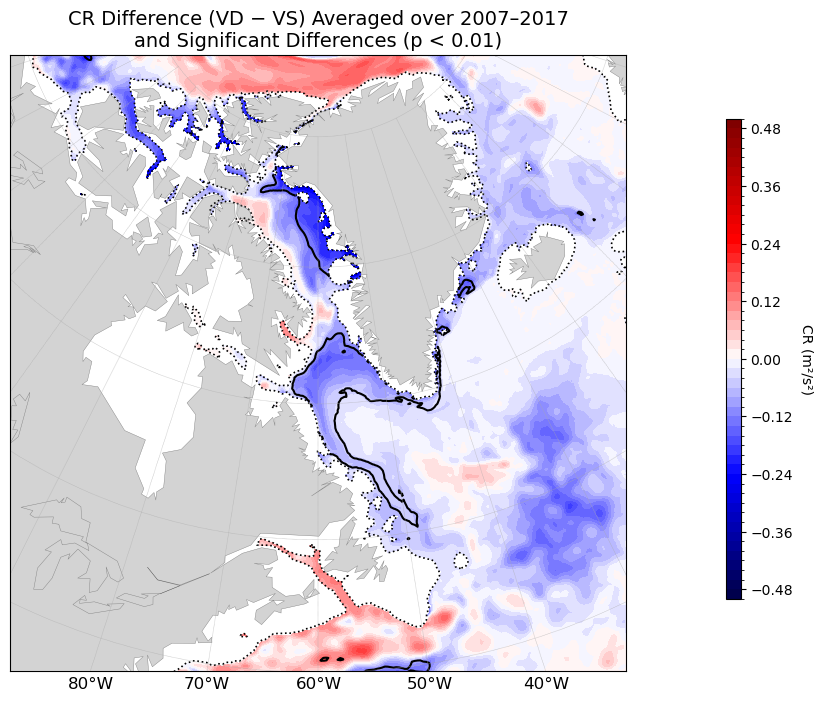

In [4]:
data_path = '.../Figure2&12_ConvectiverResistance/'
years = np.arange(2007, 2018)
vmin = -0.5
vmax = 0.5
levels = 50
lv = (vmax - vmin) / levels
levels = np.arange(vmin, vmax + lv, lv)
cmap = plt.get_cmap('seismic')
all_avg_vs = []
all_avg_vd = []

for idx, year in enumerate(years):
    print(f"▶️ Processando {year}...")

    vs_file = f'ANHA4-EJM010-S_{year}_CR.npz'
    vd_file = f'ANHA4-EJM012-S_{year}_CR.npz'
    data_vs = np.load(os.path.join(data_path, vs_file))['ConvR']
    data_vd = np.load(os.path.join(data_path, vd_file))['ConvR']

    avg_vs = np.nanmean(data_vs, axis=0)
    avg_vd = np.nanmean(data_vd, axis=0)

    all_avg_vs.append(avg_vs)
    all_avg_vd.append(avg_vd)


all_avg_vs = np.stack(all_avg_vs, axis=0)
all_avg_vd = np.stack(all_avg_vd, axis=0)

all_avg_vs = all_avg_vs.reshape(-1, 800, 544)  
all_avg_vd = all_avg_vd.reshape(-1, 800, 544)

dif = np.nanmean(all_avg_vd, axis=0) - np.nanmean(all_avg_vs, axis=0)
dif = np.clip(dif, vmin, vmax)

stat, p_val = ttest_ind(all_avg_vd, all_avg_vs, axis=0, nan_policy='omit')

########## PLOTING

fig, ax = plt.subplots(figsize=(10, 8))

m = Basemap(projection='aea', resolution='c', width=5E6, height=5E6,
            lat_0=63, lon_0=-60, ax=ax)

x, y = m(lon, lat)

m.contourf(x, y, dif, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap)

m.contour(x, y, p_val, levels=[0.01], colors='black')
bath_contour = m.contour(lon, lat, 
                             bat, latlon=True, levels=[250], 
                             colors='black', linewidths=1.2, linestyles='dotted')
m.drawcoastlines(color='gray', linewidth=0.3)
m.fillcontinents(color='lightgray', lake_color='lightgray')
m.drawmeridians(np.arange(0,360,10), labels=[0, 0, 0, 1], linewidth=0.4, color = 'darkgray', fontsize = 12)
m.drawparallels(np.arange(-90,90,10), linewidth=0.4, color = 'darkgray')

cax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('CR (m\u00B2/s\u00B2)', rotation=270, labelpad=15)

ax.set_title('CR Difference (VD − VS) Averaged over 2007–2017\nand Significant Differences (p < 0.01)', fontsize=14)

plt.savefig(os.path.join(data_path, 'CR_Diff_Overall_2007_2017_250m.png'), dpi=300)
plt.show()

In [5]:
os.chdir('.../icb_occurence')

vs = np.load('icb_count_vs.npz')
vs = vs['icb_count']

vd = np.load('icb_count_vd.npz')
vd = vd['icb_count']

occurence_dif = vd - vs


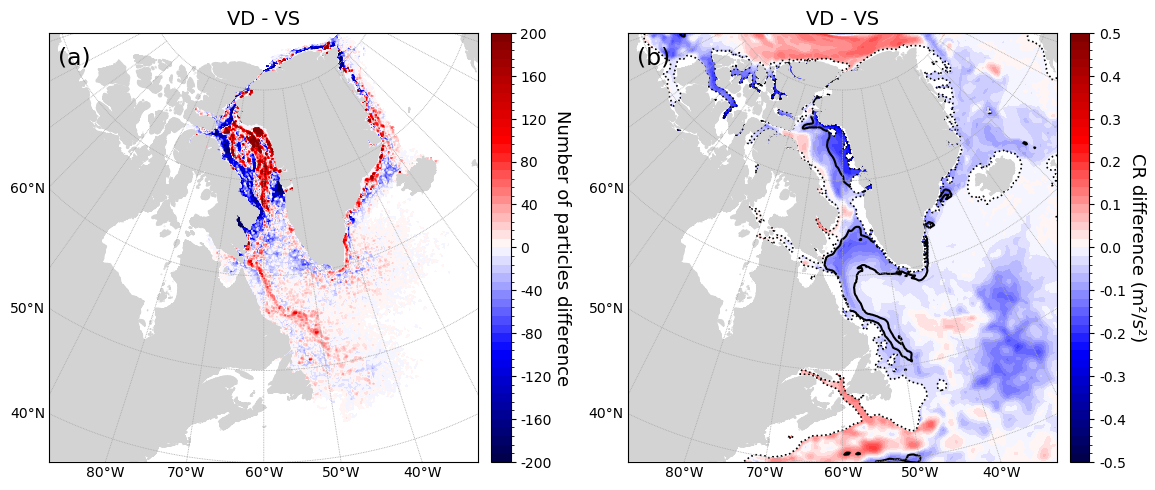

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.basemap import Basemap
import numpy as np

vmins = [-200, -0.5]
vmaxs = [200, 0.5]
levels = 50
lv = (vmaxs[1] - vmins[1]) / levels
levels_cr = list(np.arange(vmins[1], vmaxs[1] + lv, lv))

n_levels = 50
levels_oc = np.linspace(vmins[0], vmaxs[0], n_levels + 1)

levels = [levels_oc, levels_cr]

cmap = plt.get_cmap('seismic')

fig, axes = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'wspace': 0.35})

datasets = [occurence_dif, dif]
titles = ['VD - VS', 'VD - VS']
cb_labels = ['Number of particles difference', 'CR difference (m\u00B2/s\u00B2)']

for i, (ax, data, title, cb_label, vmin, vmax, level) in enumerate(zip(axes, datasets, titles, cb_labels, vmins, vmaxs, levels)):
    m = Basemap(projection='aea', resolution='f',
                width=5E6, height=5E6, lat_0=63, lon_0=-60, ax=ax)
    
    cs = m.contourf(lon, lat, np.clip(data, vmin, vmax),
                    latlon=True, levels=level, cmap=cmap, vmin=vmin, vmax=vmax)
    
    if i == 1:
        m.contour(x, y, p_val, levels=[0.01], colors='black')
        bath_contour = m.contour(lon, lat, 
                             bat, latlon=True, levels=[250], 
                             colors='black', linewidths=1.2, linestyles='dotted')
        

    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 10), labels=[0, 0, 0, 1], linewidth=0.6, color='darkgray', fontsize=10)
    m.drawparallels(np.arange(-90, 90, 10), labels=[1, 0, 0, 0], linewidth=0.6,  color='darkgray', fontsize=10)
    ax.set_title(title, fontsize=14)

    # Colorbar discreta com ticks bem distribuídos, incluindo min e max
    cax = fig.add_axes([ax.get_position().x1 + 0.01,
                        ax.get_position().y0,
                        0.015,
                        ax.get_position().height])
    norm = BoundaryNorm(level, ncolors=cmap.N, clip=True)
    
    n_ticks = 11
    ticks = np.linspace(level[0], level[-1], n_ticks)
    
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm,
                                  boundaries=level,
                                  ticks=ticks,
                                  spacing='proportional')
    cb.ax.tick_params(labelsize=10)
    if vmax > 20:
        cb.set_ticklabels([f"{t:.0f}" for t in ticks])
    else:
        cb.set_ticklabels([f"{t:.1f}" for t in ticks])
        
    cb.set_label(cb_label, rotation=270, labelpad=14, fontsize=13)

labels = ['a', 'b']

for i, ax in enumerate(axes):
    # Add corner label in the upper-left corner of each subplot
    ax.text(0.02, 0.97, f'({labels[i]})', transform=ax.transAxes,
            fontsize=17, va='top', ha='left')
    
    
figure_title = 'Occurence+CR'
os.chdir('.../Figure2&12_ConvectiverResistance/')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()

